In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import seaborn as sns
import os
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot
from scipy.stats import boxcox 
from statsmodels.tsa.seasonal import STL
from utils import load_data, check_stationarity
from plots import *

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Load & Process Data

In [3]:
data = load_data()

In [4]:
data["t_seasdiff"]= data["tdiff"].diff(12)
data_sd = data.dropna(subset=["t_seasdiff"])

## Plot time Series

In [5]:
data

,date,tmax,tmin,tmed,month,year,prec,tdiff,log_diff,lagged_tdiff_1,...,lagged_prec_12,lagged_tmed_12,lagged_tmax_12,lagged_tmin_12,lagged_tdiff_24,lagged_prec_24,lagged_tmed_24,lagged_tmax_24,lagged_tmin_24,t_seasdiff
date,,,,,,,,,,,,,,,,,,,,,
1994-01-01,1994-01-01,13.08,4.59,8.84,1,1994,145.2,8.49,2.138889,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994-02-01,1994-02-01,13.51,4.71,9.11,2,1994,130.6,8.80,2.174752,8.49,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994-03-01,1994-03-01,19.63,8.29,13.96,3,1994,11.1,11.34,2.428336,8.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994-04-01,1994-04-01,18.54,7.25,12.89,4,1994,43.2,11.29,2.423917,11.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994-05-01,1994-05-01,20.15,10.77,15.46,5,1994,160.2,9.38,2.238580,11.29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-09-01,2019-09-01,28.00,13.90,20.95,9,2019,19.8,14.10,2.646175,14.34,...,8.1,23.00,30.21,15.79,15.07,2.0,19.95,27.49,12.42,-0.32
2019-10-01,2019-10-01,22.42,11.08,16.75,10,2019,79.3,11.34,2.428336,14.10,...,70.4,16.64,22.61,10.67,15.08,26.9,19.57,27.11,12.03,-0.60
2019-11-01,2019-11-01,15.71,8.53,12.12,11,2019,160.8,7.18,1.971299,11.34,...,178.0,11.87,15.83,7.91,11.95,56.9,12.84,18.81,6.86,-0.74


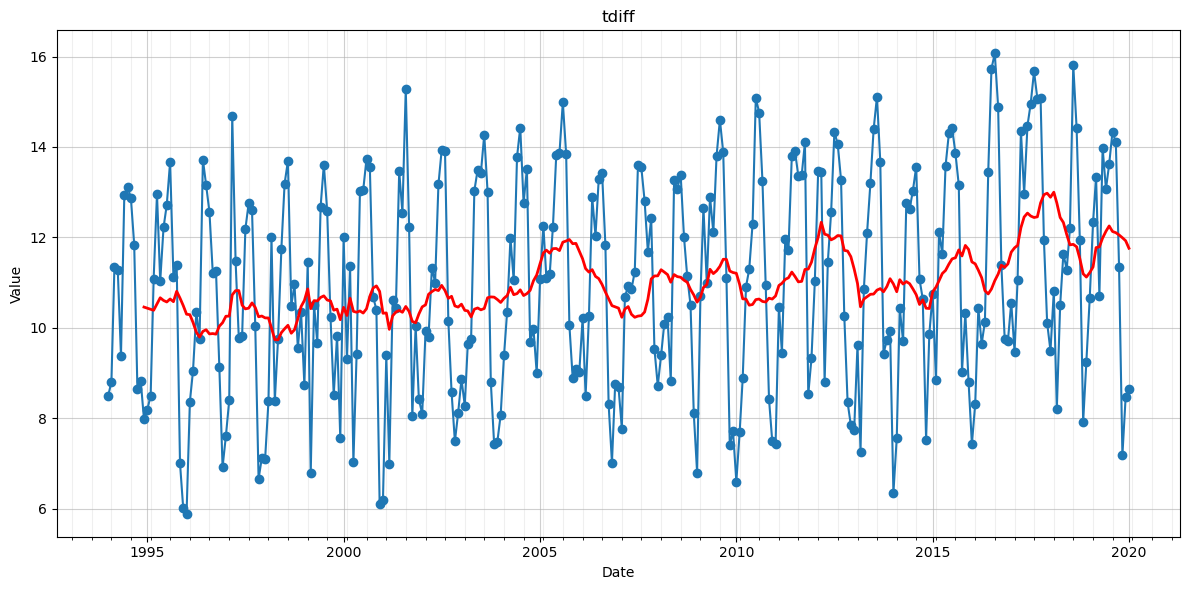

In [6]:
plot_time_series(data, 'date', 'tdiff', ma_window=12)

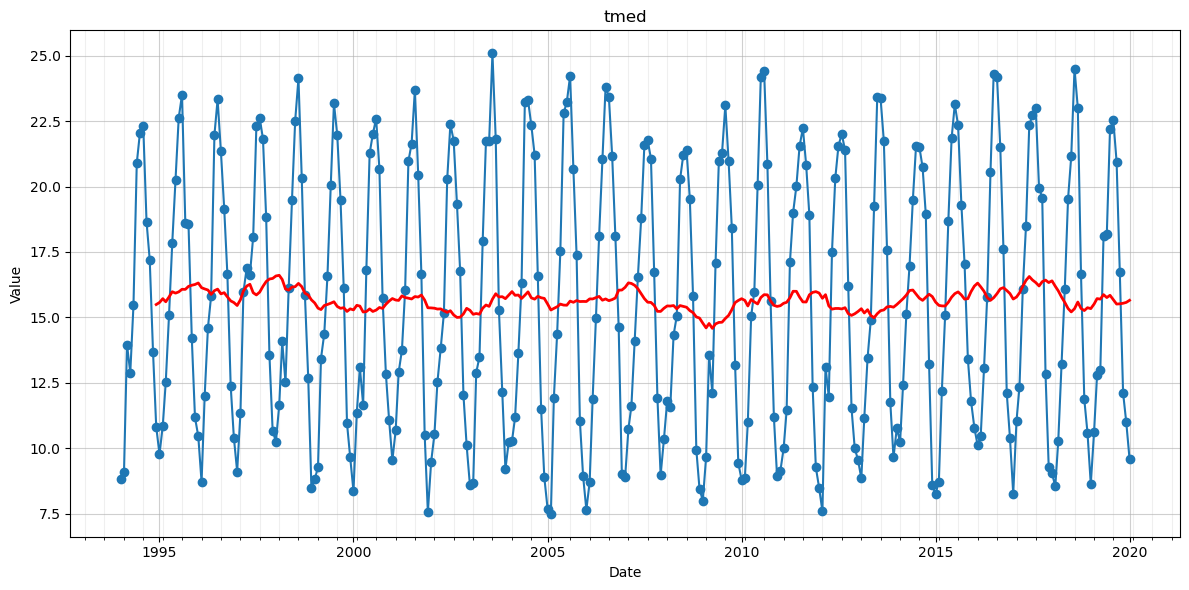

In [7]:
plot_time_series(data, 'date', 'tmed', ma_window=12)

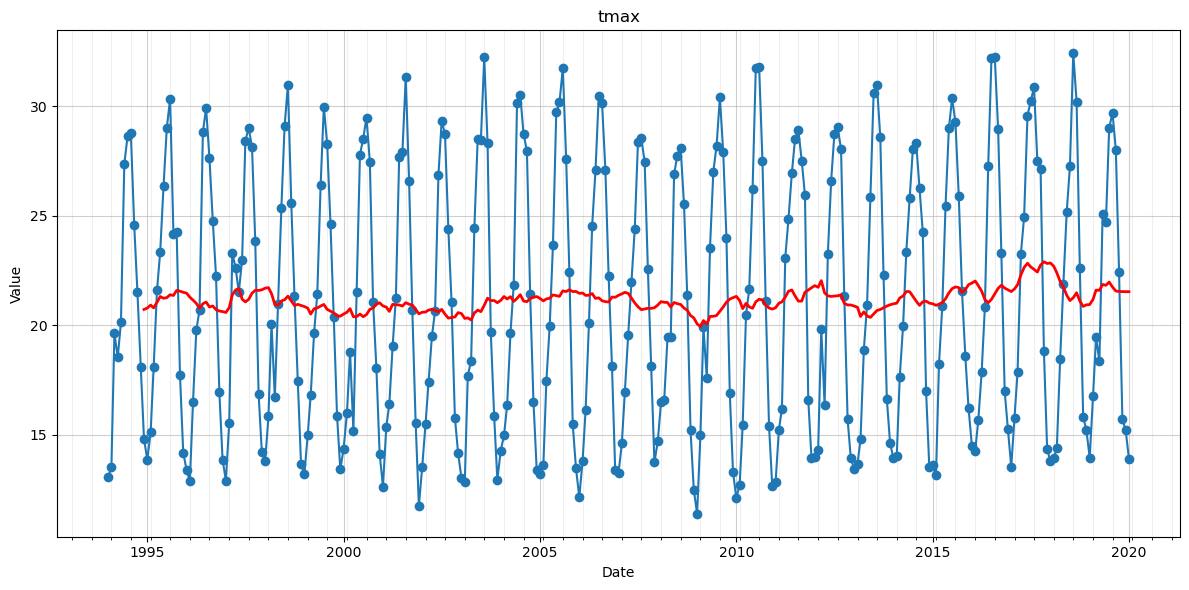

In [8]:
plot_time_series(data, 'date', 'tmax', ma_window=12)

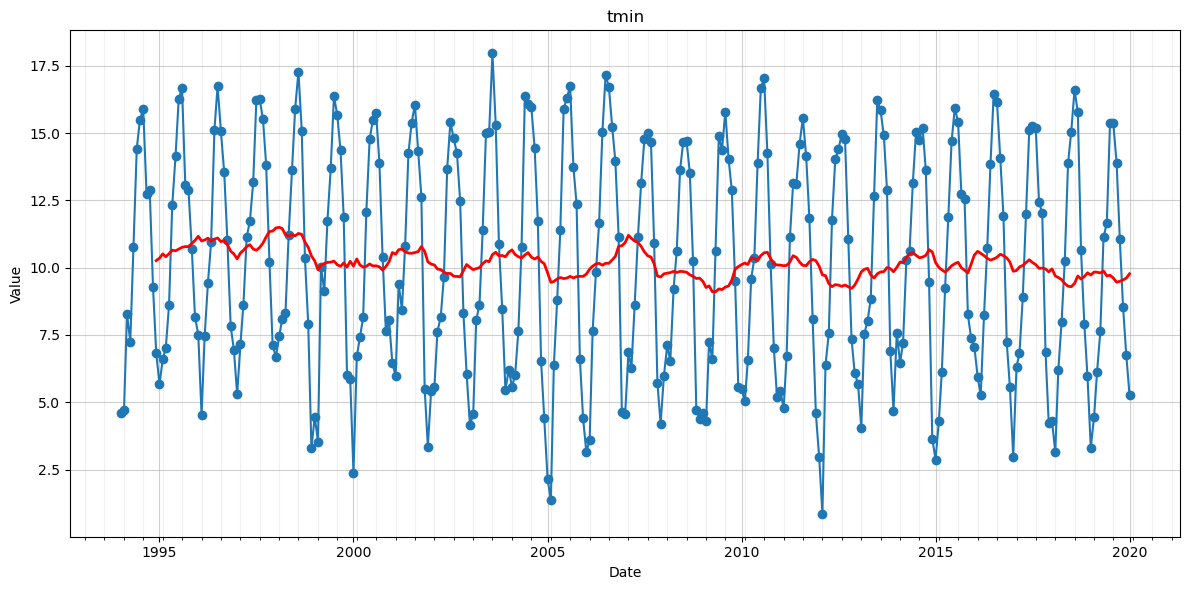

In [9]:
plot_time_series(data, 'date', 'tmin', ma_window=12)

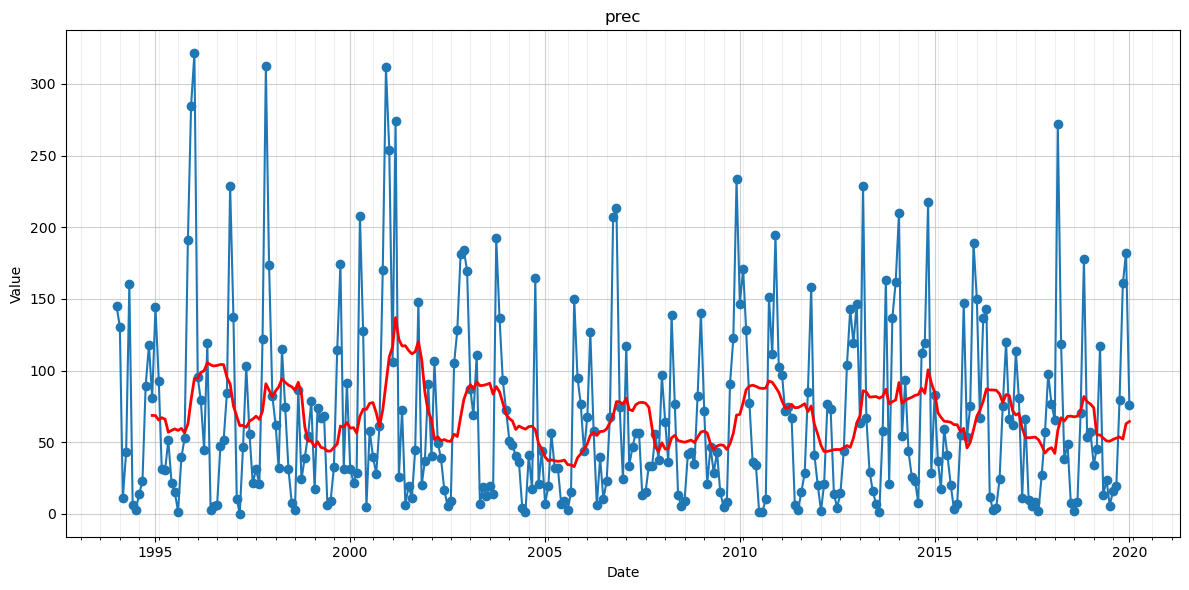

In [10]:
plot_time_series(data, 'date', 'prec', ma_window=12)

### Log Feat

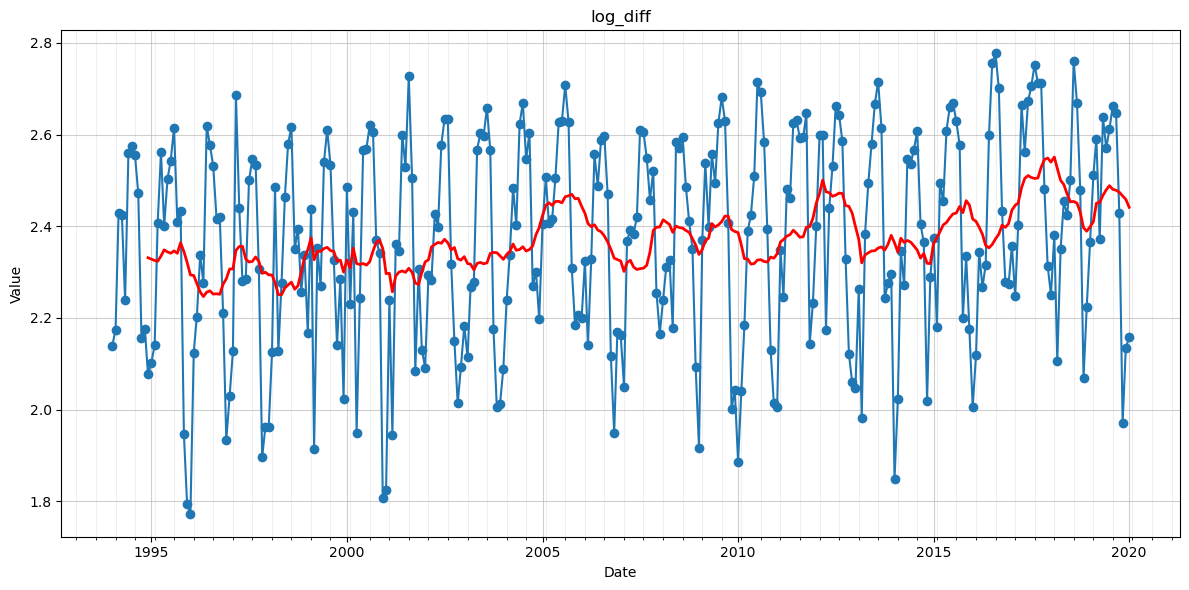

In [11]:
plot_time_series(data, 'date', 'log_diff', ma_window=12)

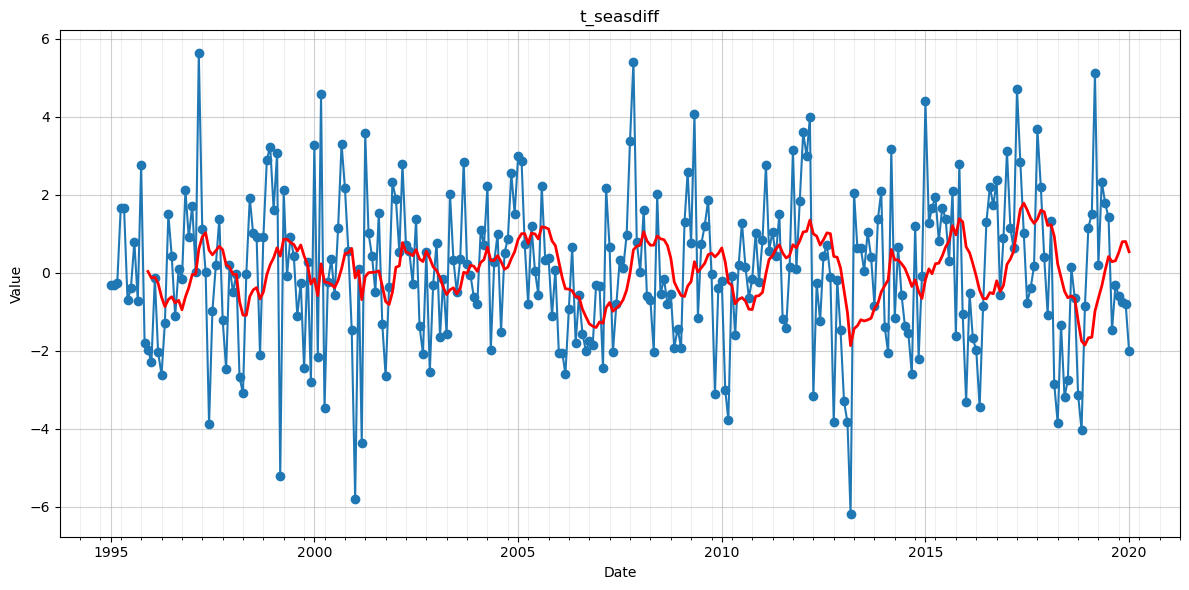

In [12]:
plot_time_series(data_sd, 'date', 't_seasdiff', ma_window=12)

## Seasonal Plot

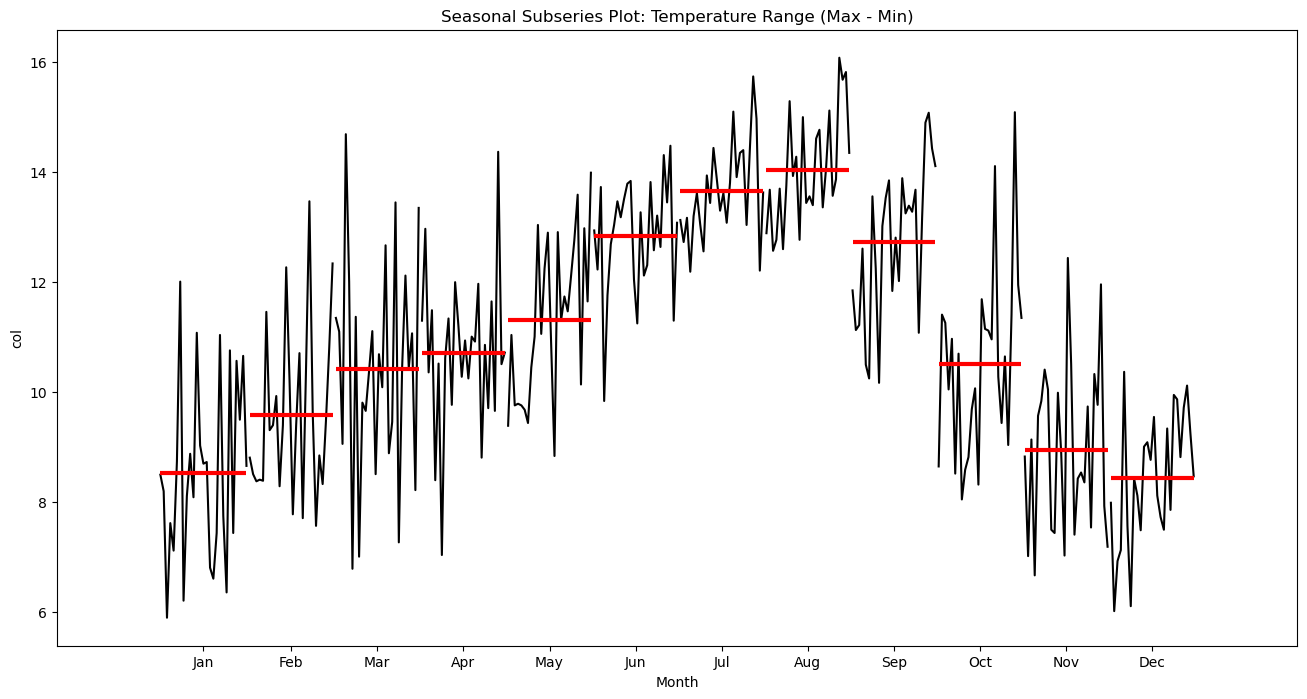

In [13]:
seasonal_plot(data, 'tdiff', "Seasonal Subseries Plot: Temperature Range (Max - Min)")

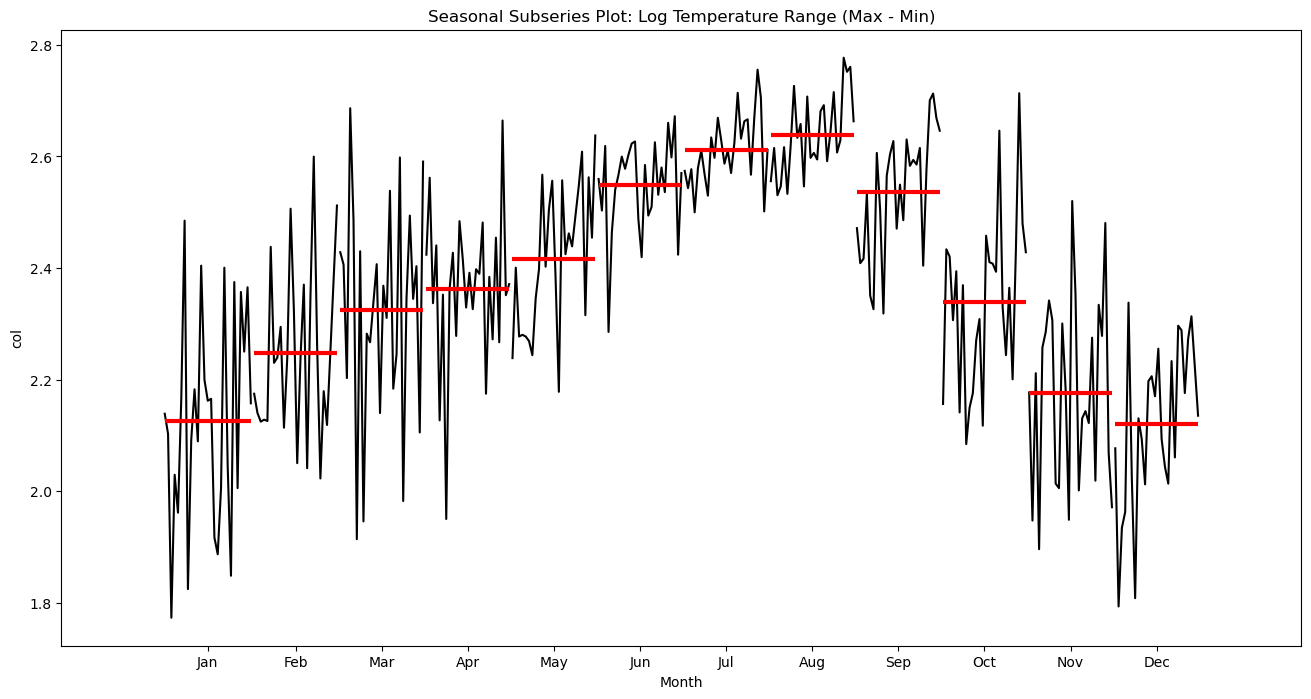

In [14]:
seasonal_plot(data, 'log_diff', "Seasonal Subseries Plot: Log Temperature Range (Max - Min)")

## Box Cox

Estimated Lambda: 0.9158332646569056


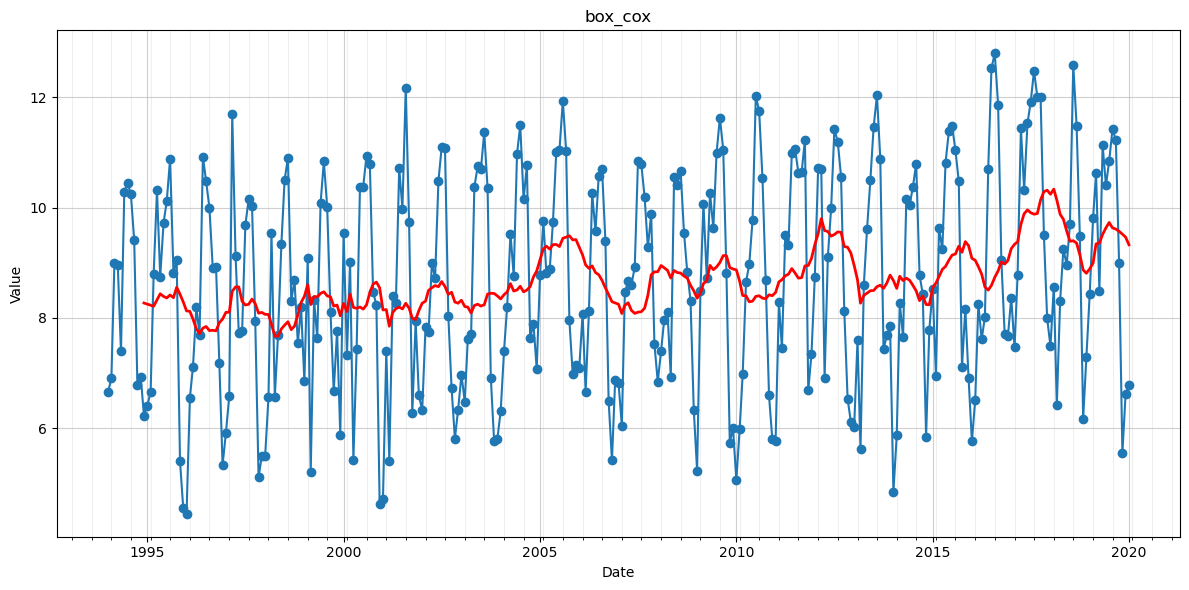

In [15]:
bc, lambda_ = boxcox(data['tdiff'])
print(f"Estimated Lambda: {lambda_}")

plot_time_series(pd.DataFrame.from_dict({
    "date": list(data.index),
    "box_cox": bc
}), 'date', 'box_cox', ma_window=12)

Estimated Lambda: 2.951904858060347


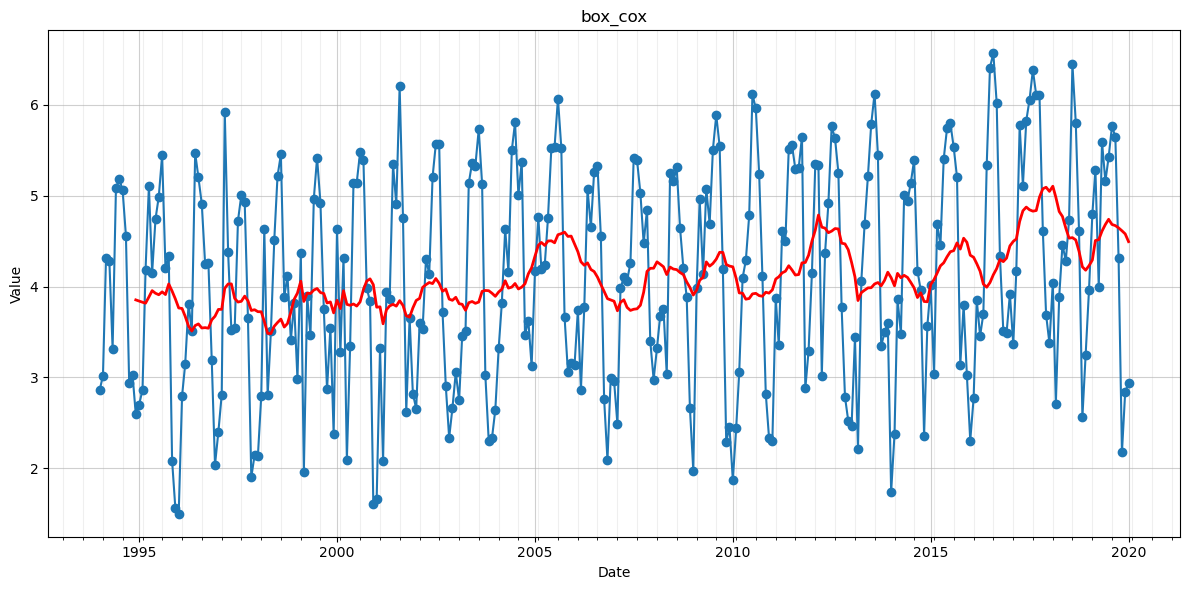

In [16]:
bc, lambda_ = boxcox(data['log_diff'])
print(f"Estimated Lambda: {lambda_}")

plot_time_series(pd.DataFrame.from_dict({
    "date": list(data.index),
    "box_cox": bc
}), 'date', 'box_cox', ma_window=12)

## Linear Regression

In [17]:
import statsmodels.formula.api as smf 
data['time'] = data['date'].dt.to_period('M').astype(int) 

# fir linear regression model
fit = smf.ols(formula='tdiff ~ time', data=data).fit()
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                  tdiff   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     12.35
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           0.000507
Time:                        23:32:33   Log-Likelihood:                -704.62
No. Observations:                 313   AIC:                             1413.
Df Residuals:                     311   BIC:                             1421.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.7085      0.654     13.324      0.0

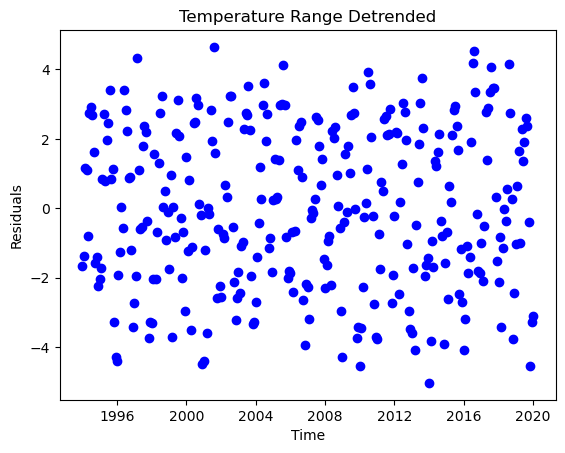

In [18]:
residuals = fit.resid
# Resíduos: detrended time series
plt.subplot(1, 1, 1)
plt.scatter(data['date'], residuals, color='blue')
plt.title("Temperature Range Detrended")
plt.ylabel("Residuals")
plt.xlabel("Time")

plt.show()

                            OLS Regression Results                            
Dep. Variable:                  tdiff   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     12.35
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           0.000507
Time:                        23:32:33   Log-Likelihood:                -704.62
No. Observations:                 313   AIC:                             1413.
Df Residuals:                     311   BIC:                             1421.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.7085      0.654     13.324      0.0

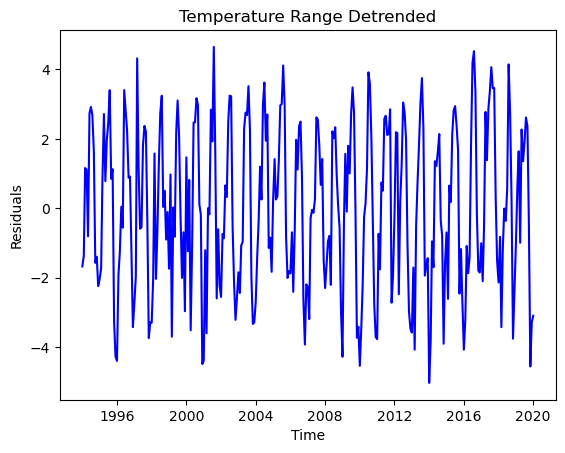

In [19]:
import statsmodels.formula.api as smf 

data['time'] = data['date'].dt.to_period('M').astype(int) 

# fir linear regression model
fit = smf.ols(formula='tdiff ~ time', data=data).fit()
print(fit.summary())

residuals = fit.resid
# Resíduos: detrended time series
plt.subplot(1, 1, 1)
plt.plot(data['date'], residuals, color='blue')
plt.title("Temperature Range Detrended")
plt.ylabel("Residuals")
plt.xlabel("Time")

plt.show()

## Difference Operator

In [20]:
tdiff_series = data['tdiff']
tdiff_diff = tdiff_series.diff(1)
tdiff_diff

date
1994-01-01     NaN
1994-02-01    0.31
1994-03-01    2.54
1994-04-01   -0.05
1994-05-01   -1.91
              ... 
2019-09-01   -0.24
2019-10-01   -2.76
2019-11-01   -4.16
2019-12-01    1.28
2020-01-01    0.19
Name: tdiff, Length: 313, dtype: float64

Text(0.5, 0, 'date')

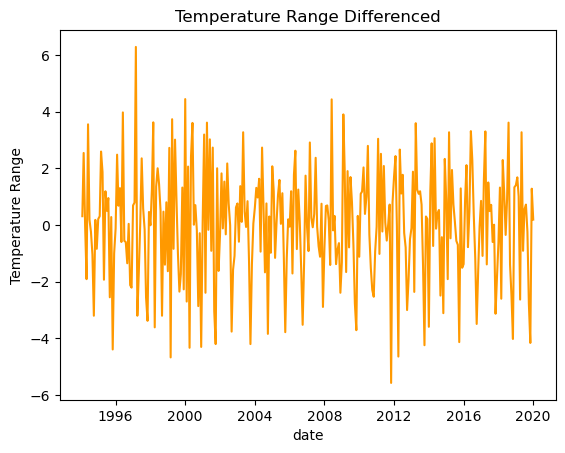

In [21]:
plt.plot(data.index, tdiff_diff, color='#ff9900')
plt.title("Temperature Range Differenced")
plt.ylabel("Temperature Range")
plt.xlabel("date")

In [22]:
diff12 = tdiff_diff.to_frame()
diff12['year_month'] = pd.to_datetime(diff12.index)
diff12

,tdiff,year_month
date,,
1994-01-01,NaN,1994-01-01
1994-02-01,0.31,1994-02-01
1994-03-01,2.54,1994-03-01
1994-04-01,-0.05,1994-04-01
1994-05-01,-1.91,1994-05-01
...,...,...
2019-09-01,-0.24,2019-09-01
2019-10-01,-2.76,2019-10-01
2019-11-01,-4.16,2019-11-01


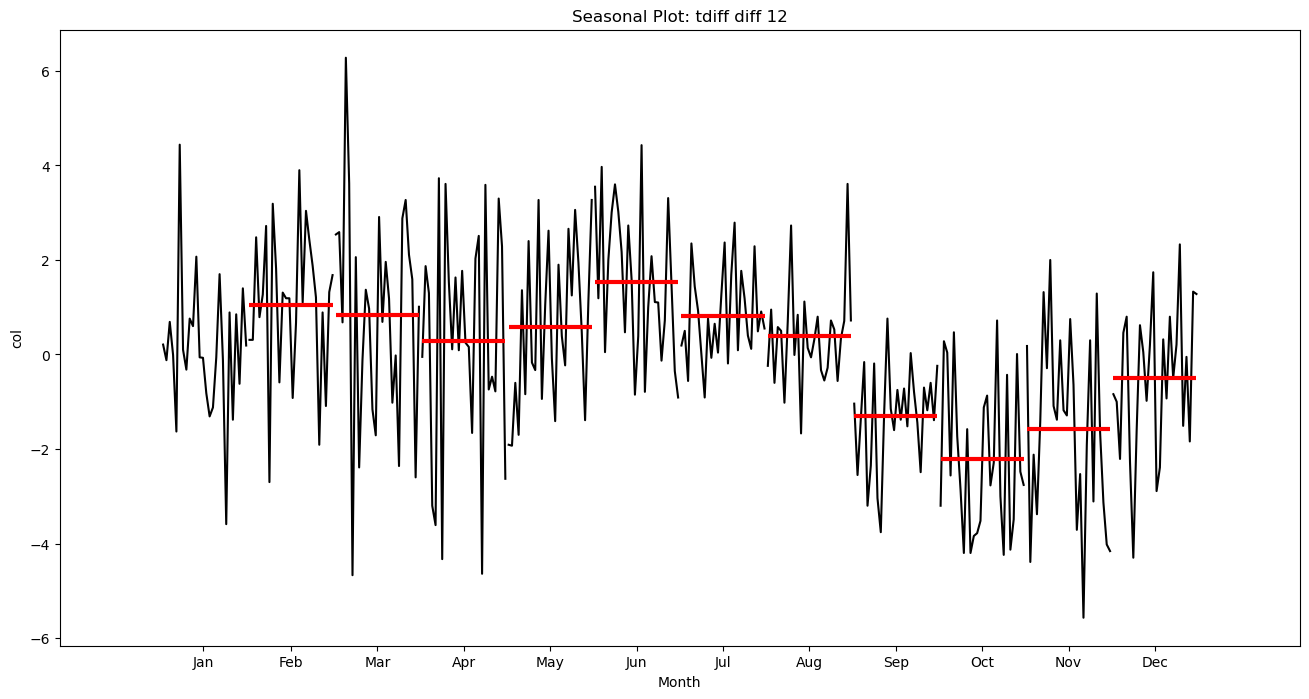

In [23]:
diff12 = tdiff_diff.to_frame()
diff12['year_month'] = pd.to_datetime(diff12.index)

x = diff12[['year_month','tdiff']]
x = x.set_index('year_month')

seasonal_plot(x, 'tdiff', "Seasonal Plot: tdiff diff 12")


## STL Decomposition

In [24]:
# STL with periodic seasonal component
stl_1 = STL(data['tdiff'], seasonal=len(data), robust=True).fit()

# STL with seasonal window of 13
stl_2 = STL(data['tdiff'], seasonal=13, robust=True).fit()

Periodic Season


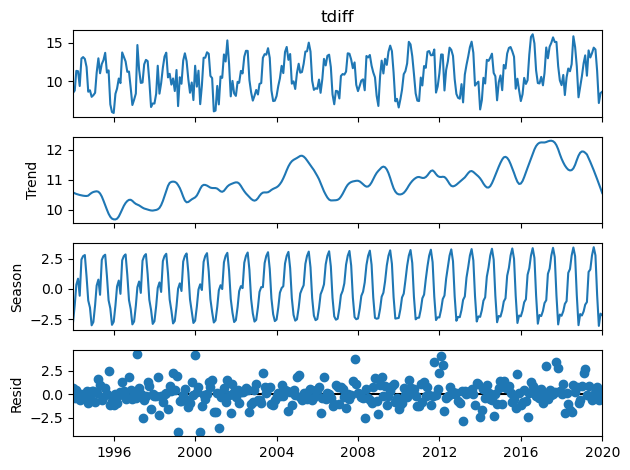

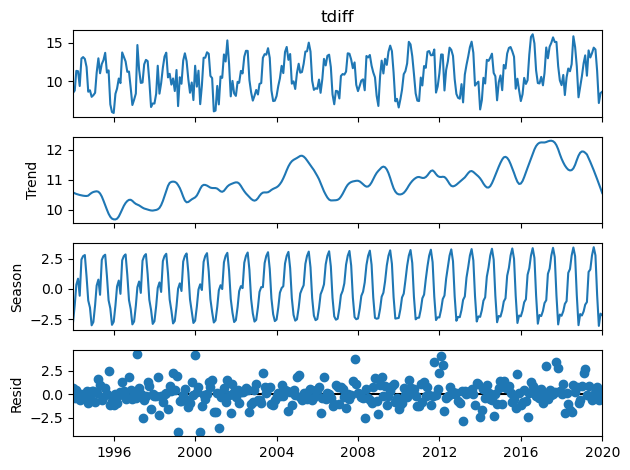

In [25]:
print("Periodic Season")
stl_1.plot()

13 Season


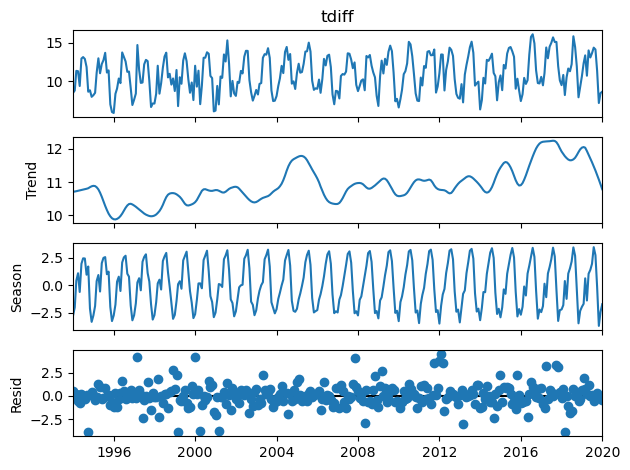

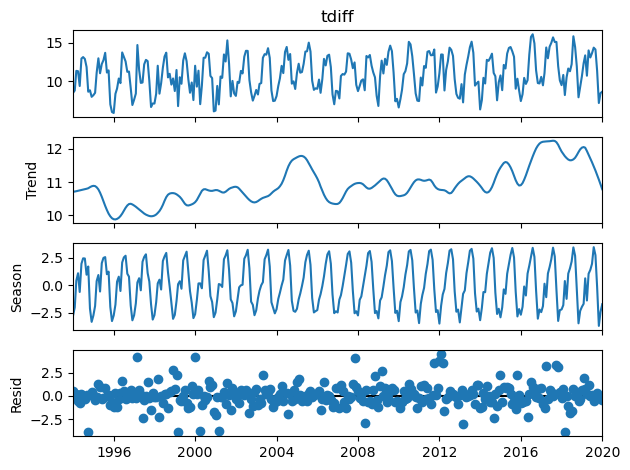

In [26]:
print("13 Season")
stl_2.plot()

In [27]:
from statsmodels.stats.diagnostic import het_arch
print(het_arch(stl_1.resid)) # Not heteroskedascity, null would be homoskedascity, and p-value >> 0.05

(np.float64(7.691397048350425), np.float64(0.6589518549781587), 0.7605223537920554, 0.666857109030305)


In [28]:
print(het_arch(stl_1.resid, nlags=12)) 

(np.float64(9.1271506045144), np.float64(0.6920334198259893), 0.7505035667484523, 0.7011315072464113)


## Lag Plots

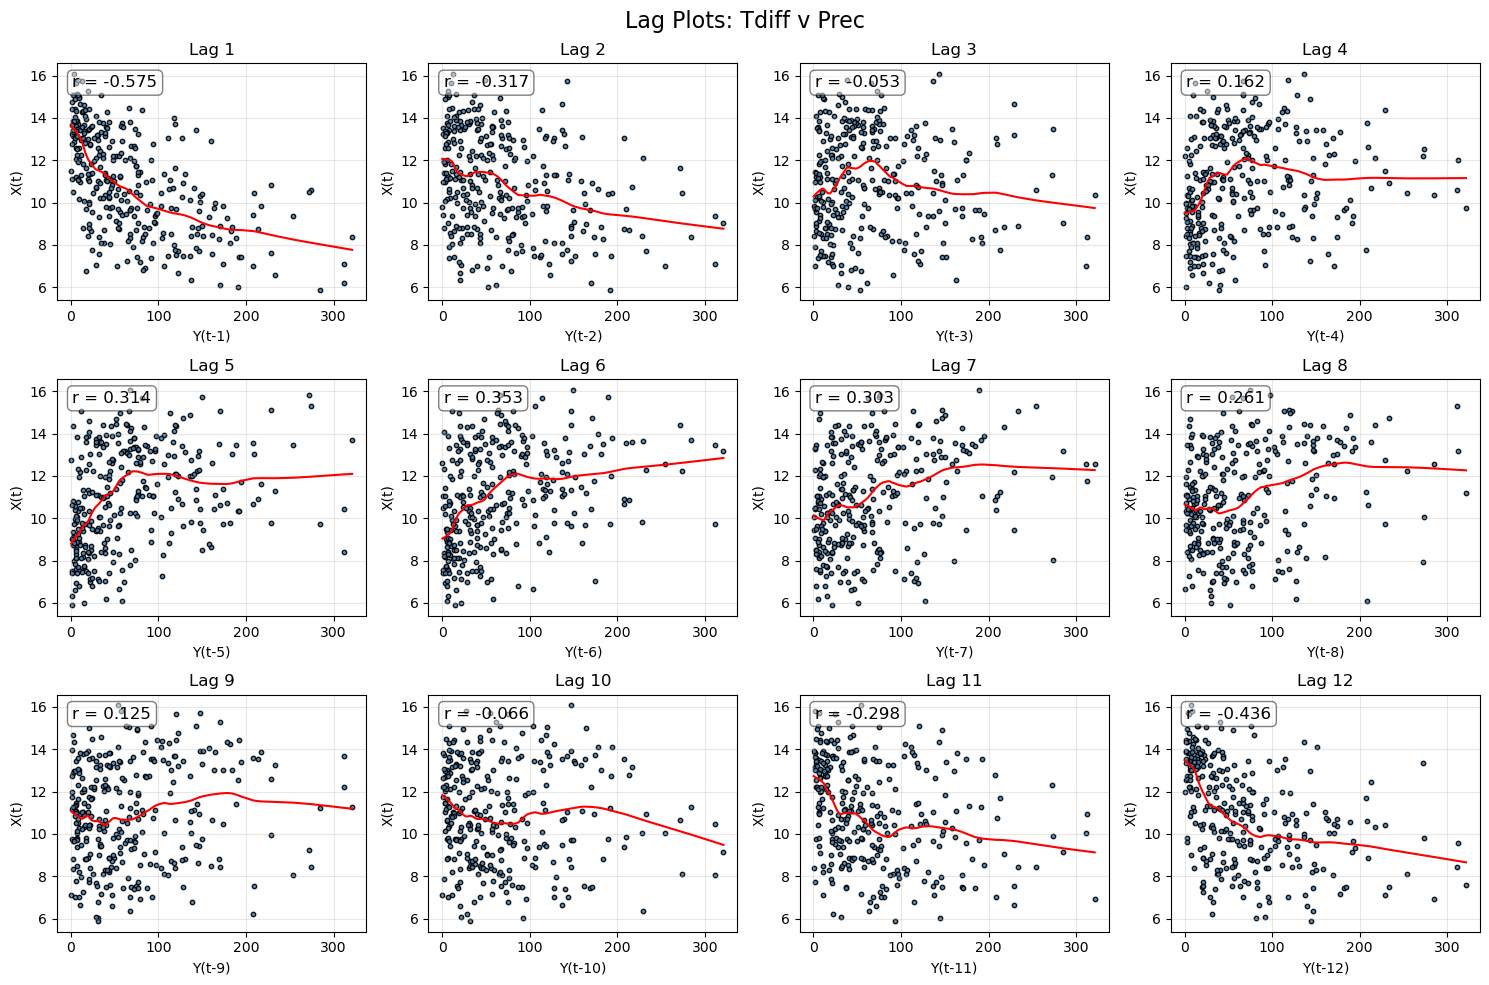

In [29]:
lag_plot_grid(data['tdiff'], ys=data['prec'], title="Lag Plots: Tdiff v Prec")

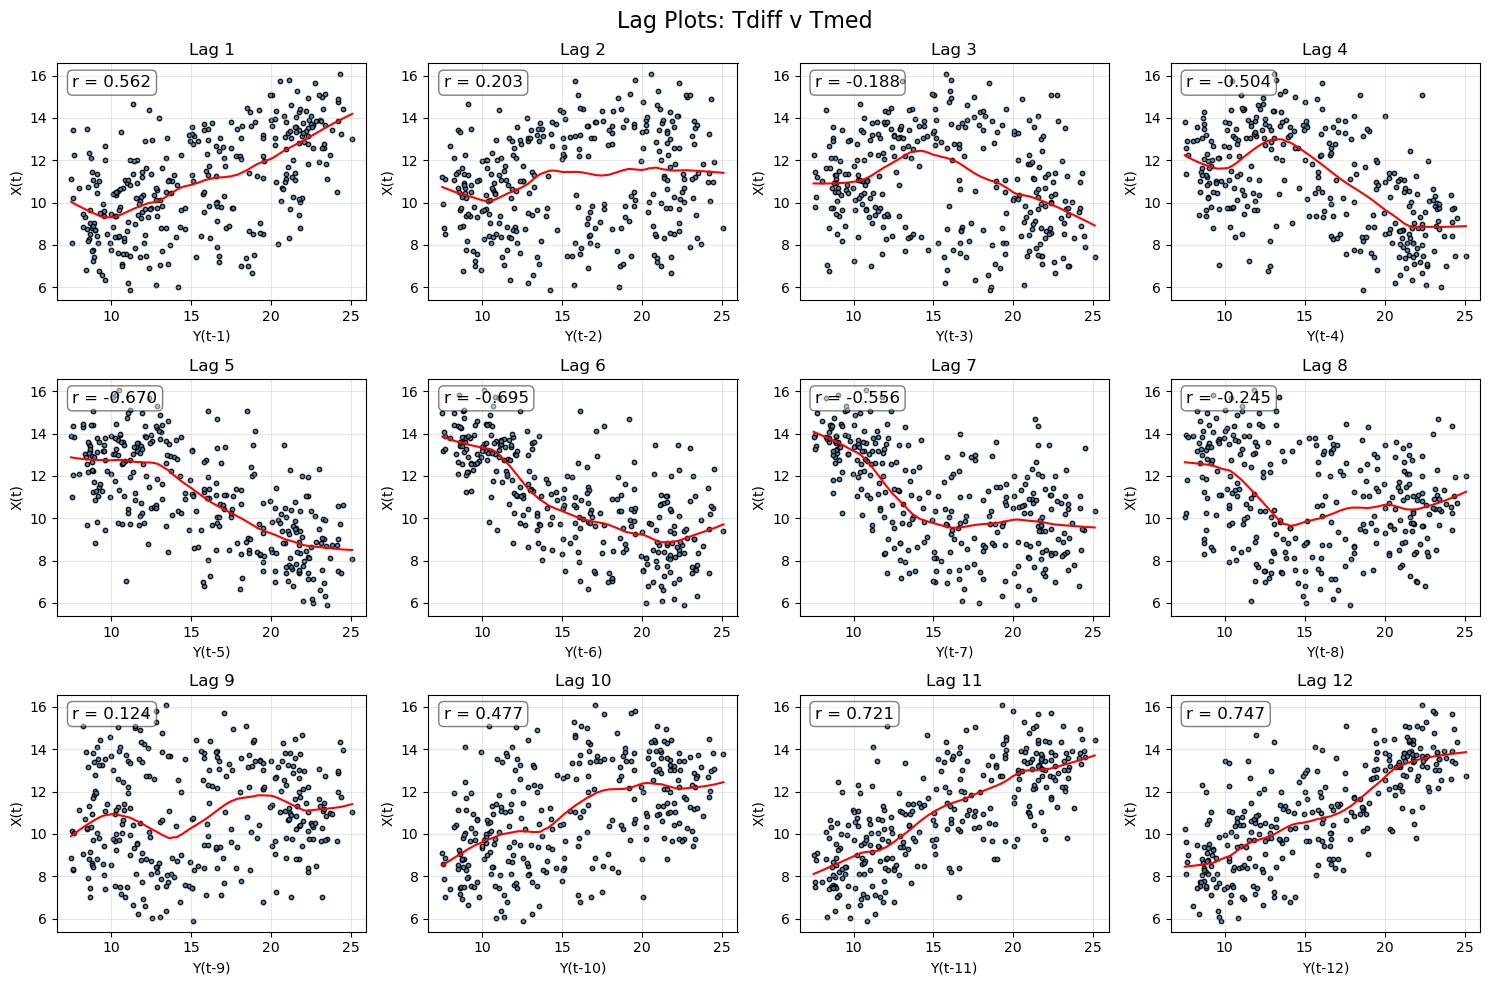

In [30]:
lag_plot_grid(data['tdiff'], ys=data['tmed'], title="Lag Plots: Tdiff v Tmed")

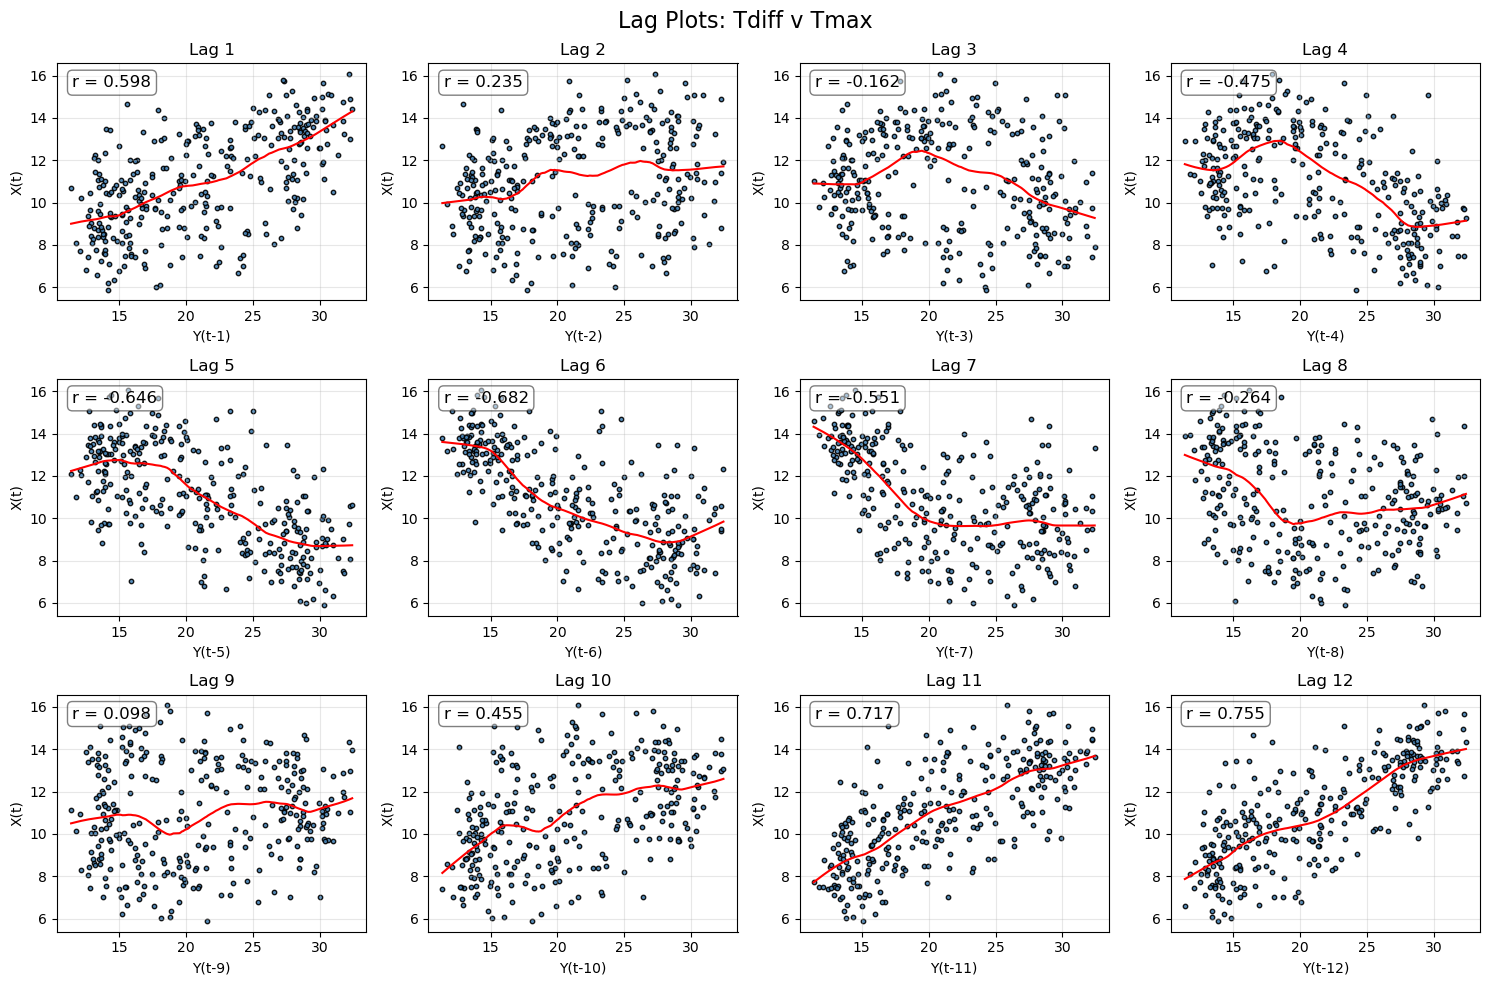

In [31]:
lag_plot_grid(data['tdiff'], ys=data['tmax'], title="Lag Plots: Tdiff v Tmax")

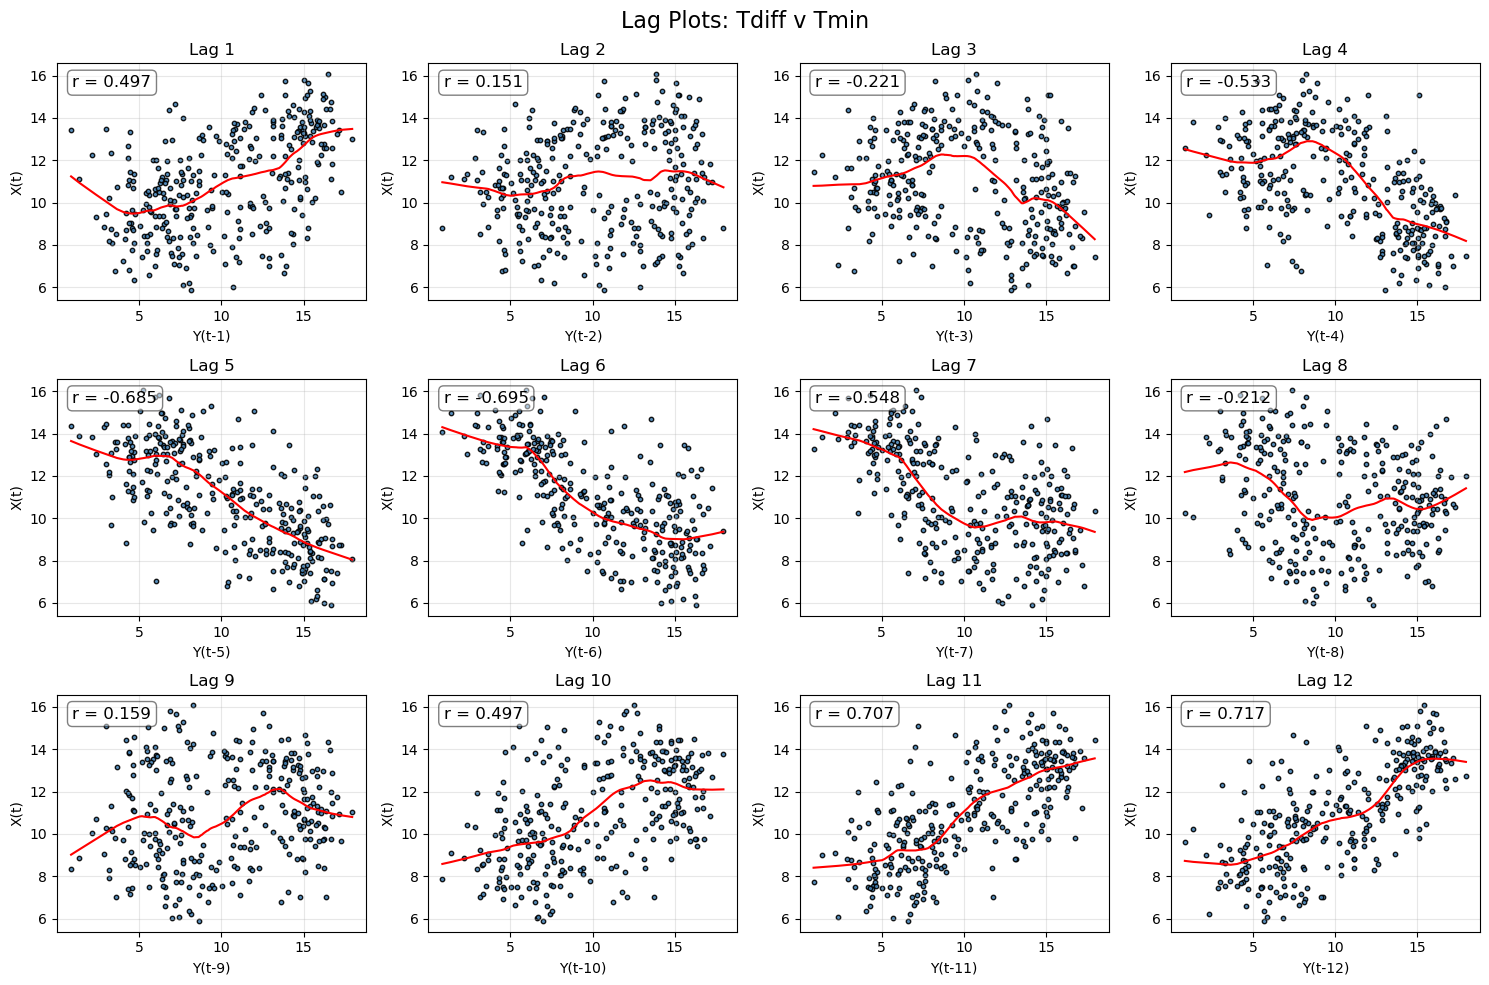

In [32]:
lag_plot_grid(data['tdiff'], ys=data['tmin'], title="Lag Plots: Tdiff v Tmin")

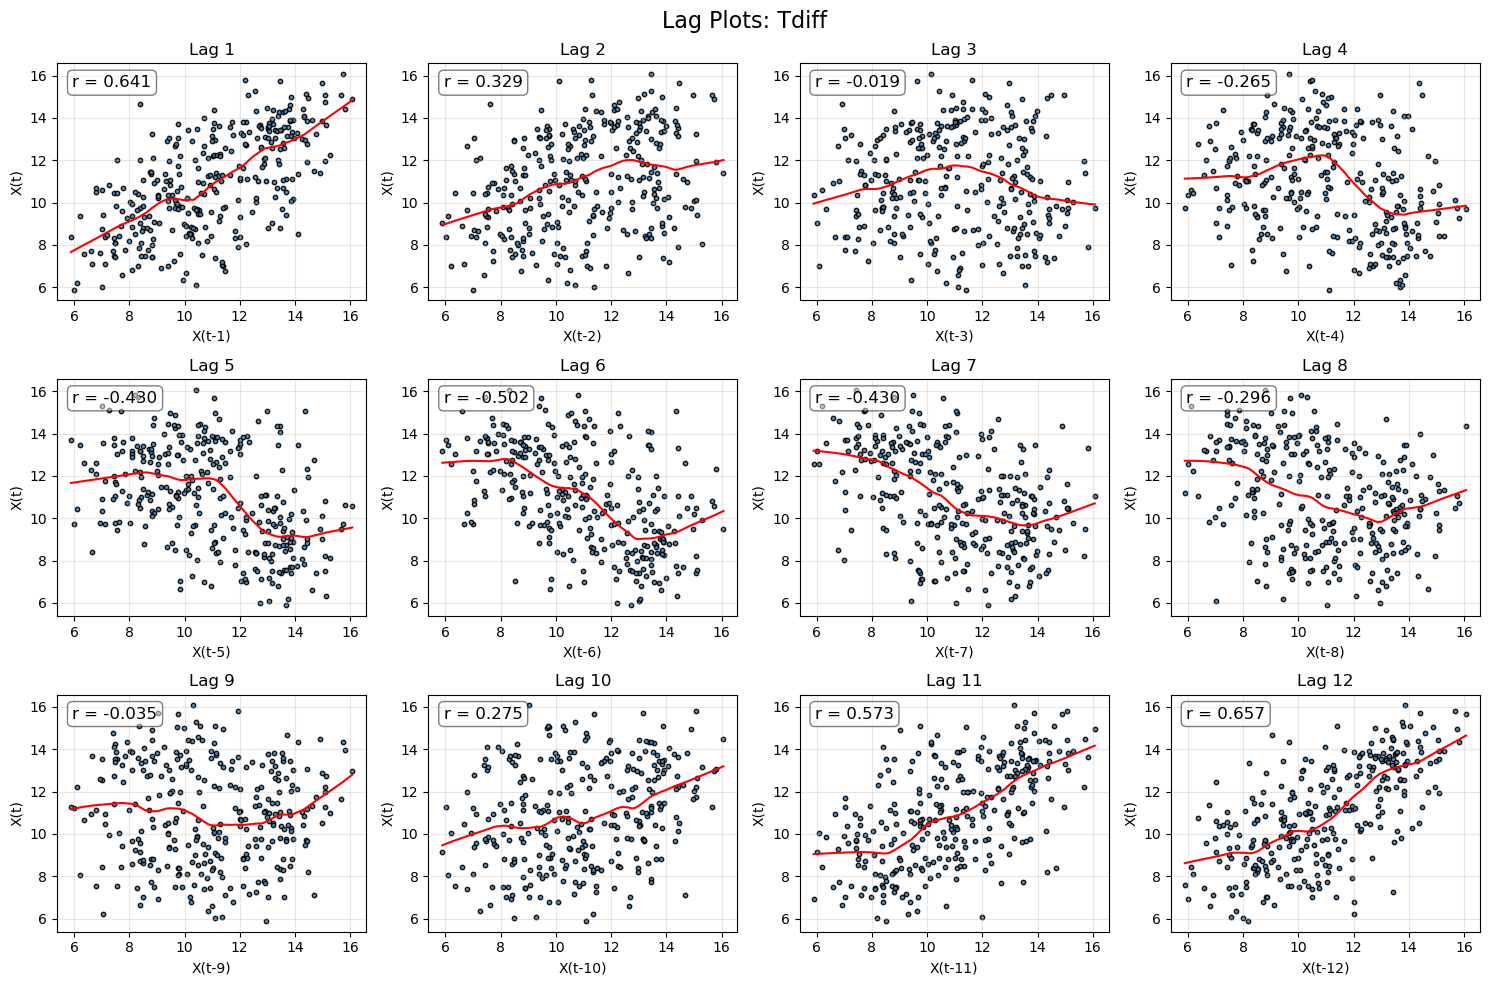

In [33]:
lag_plot_grid(data['tdiff'], title="Lag Plots: Tdiff")

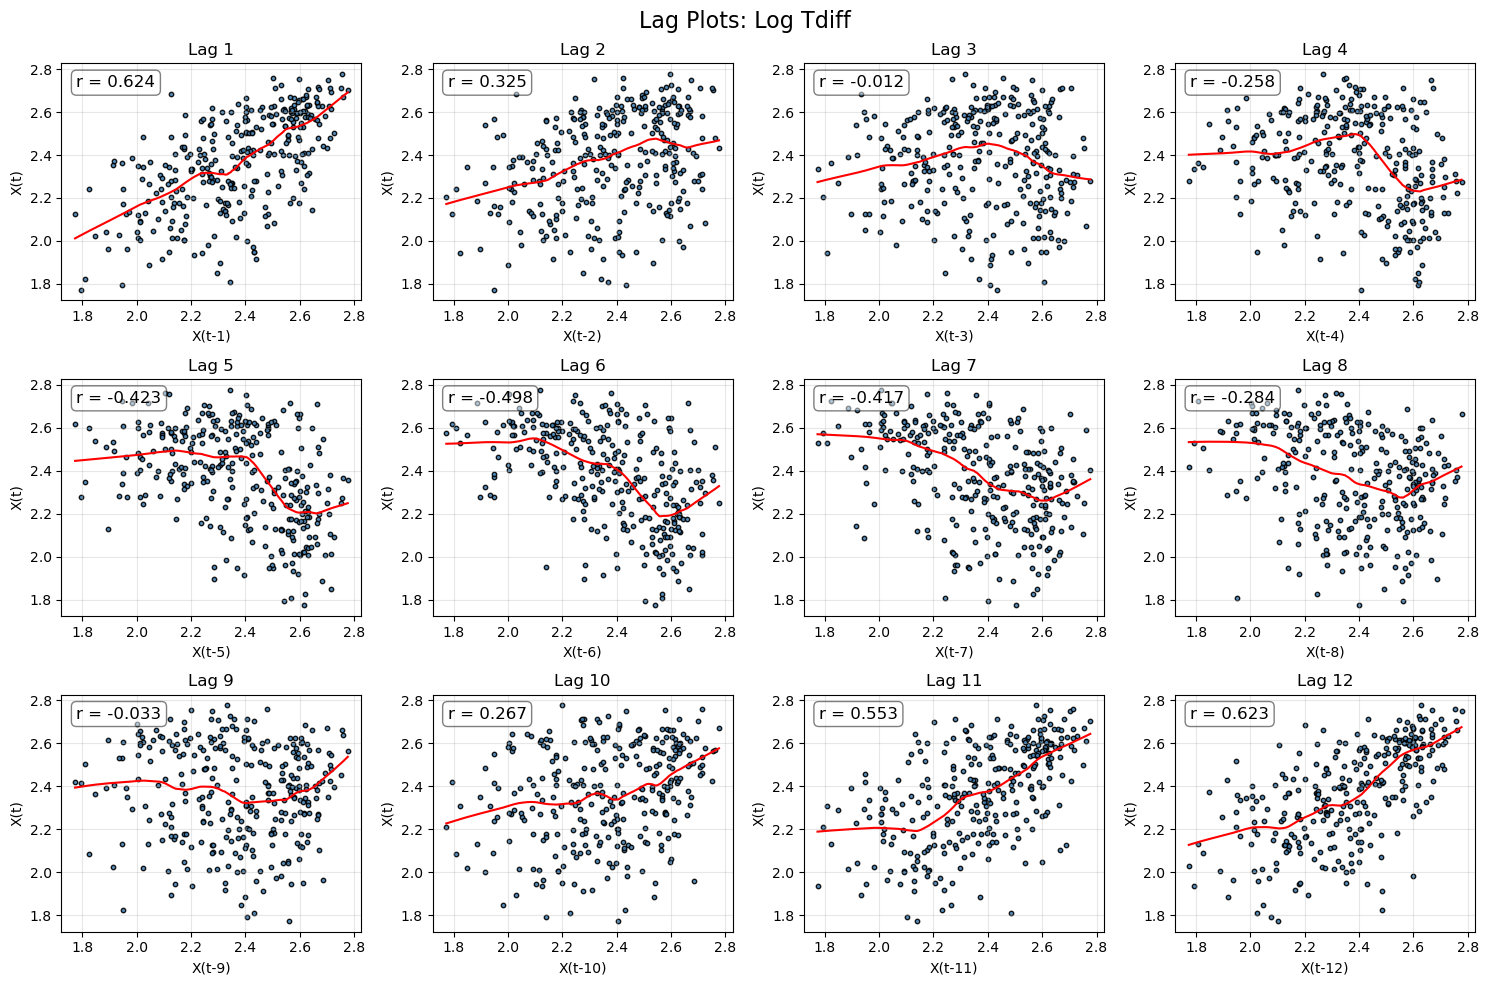

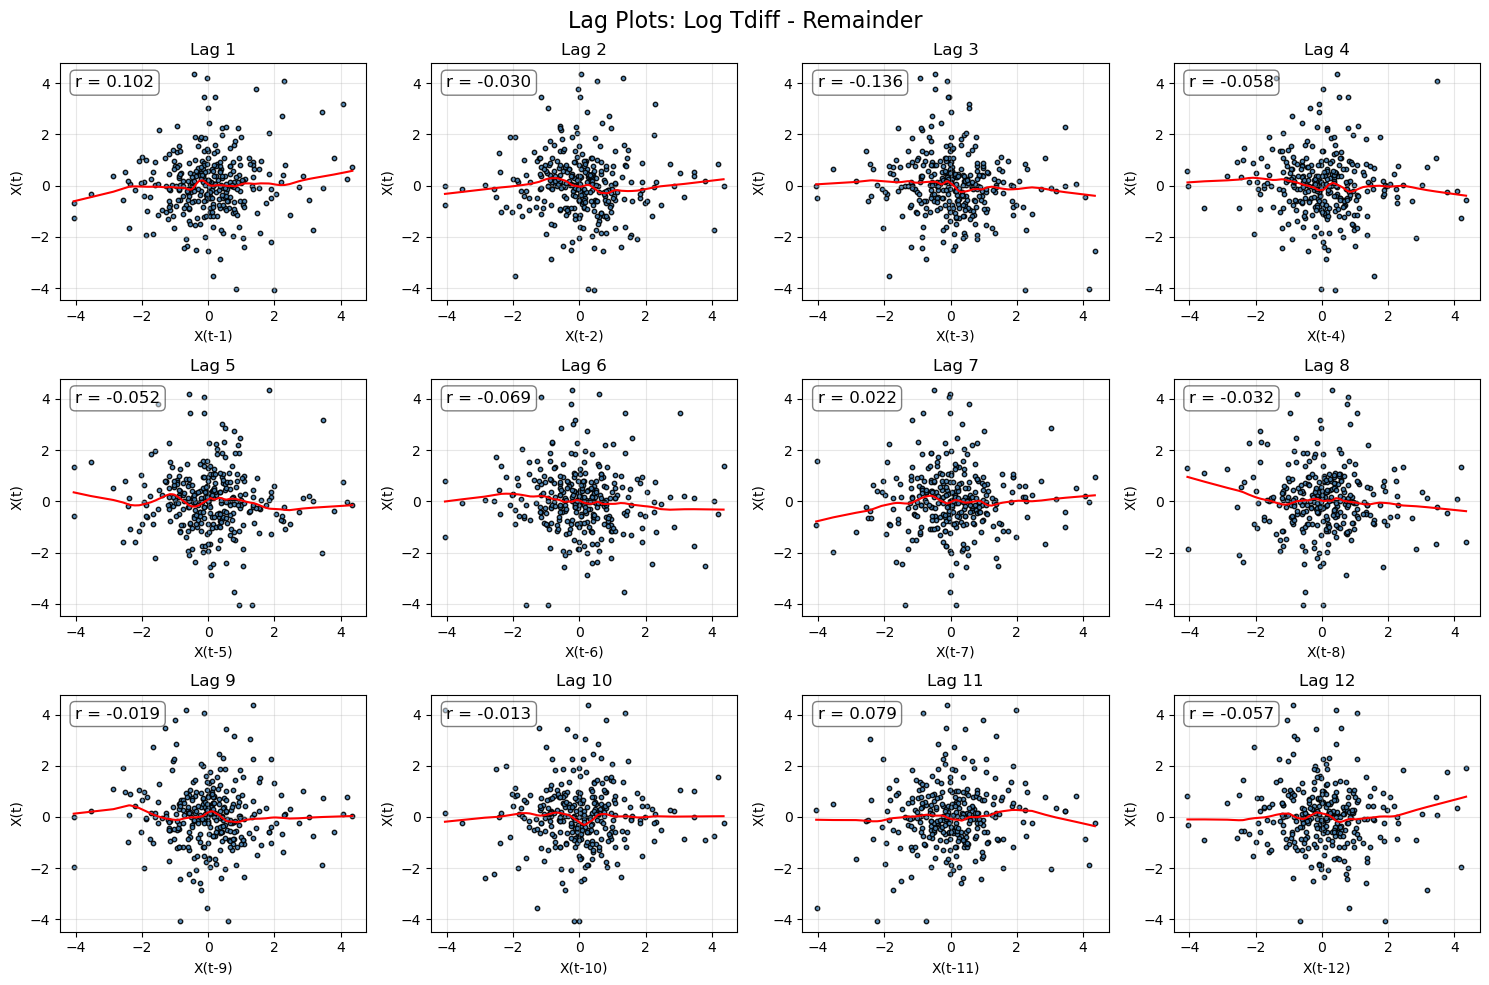

In [34]:
lag_plot_grid(data['log_diff'], title="Lag Plots: Log Tdiff")
lag_plot_grid(stl_1.resid, title="Lag Plots: Log Tdiff - Remainder")

## ACF

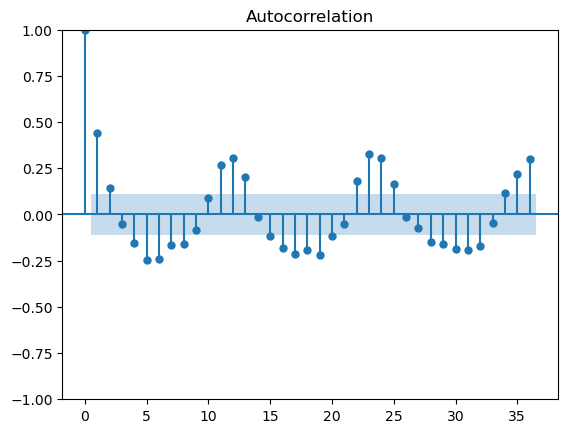

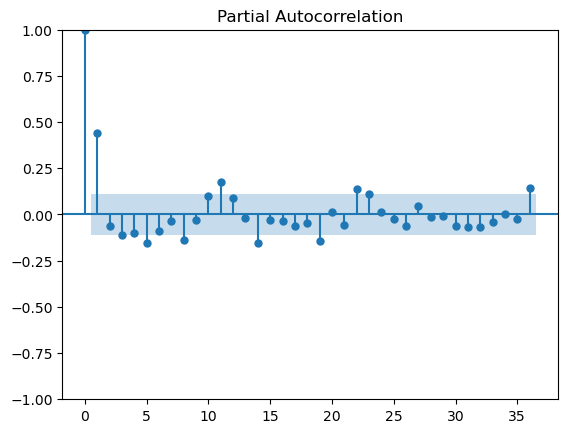

In [35]:
plot_acfs(data, 'prec')

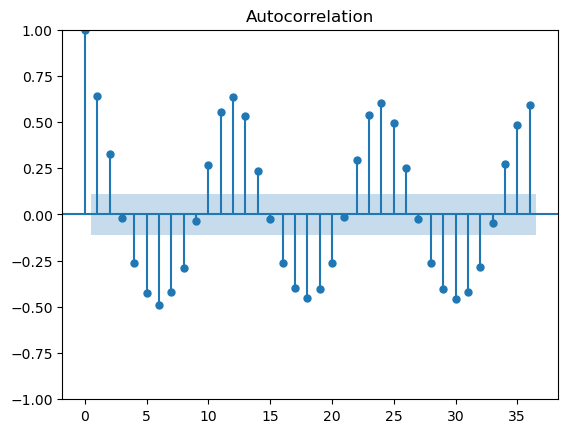

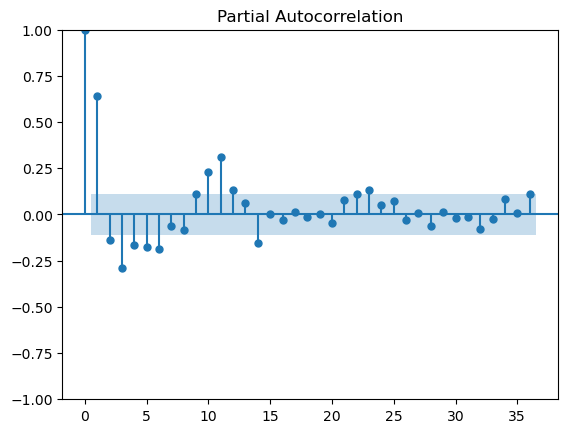

In [36]:
plot_acfs(data, 'tdiff')

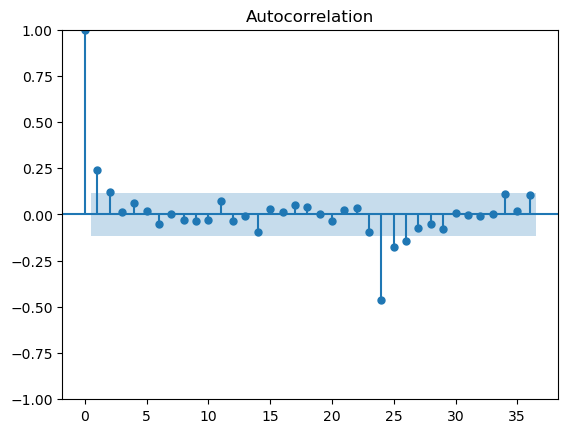

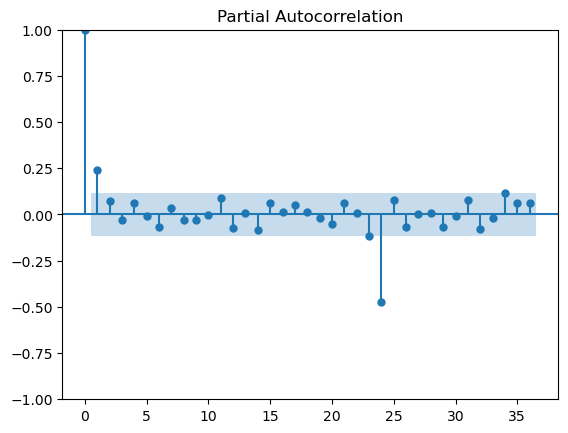

In [42]:
data["t_diff"]= data["tdiff"].diff(24)
data_diff = data.dropna(subset=["t_diff"])
plot_acfs(data_diff, 't_diff')

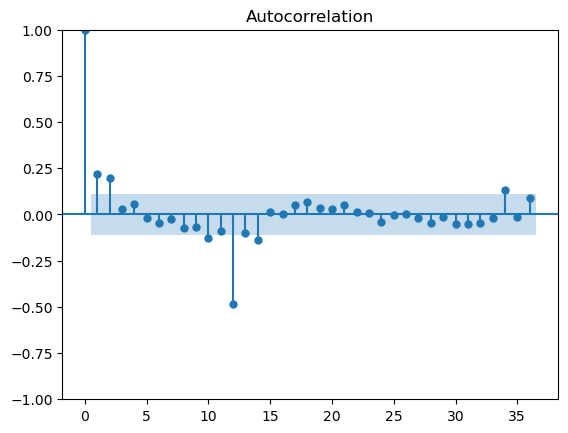

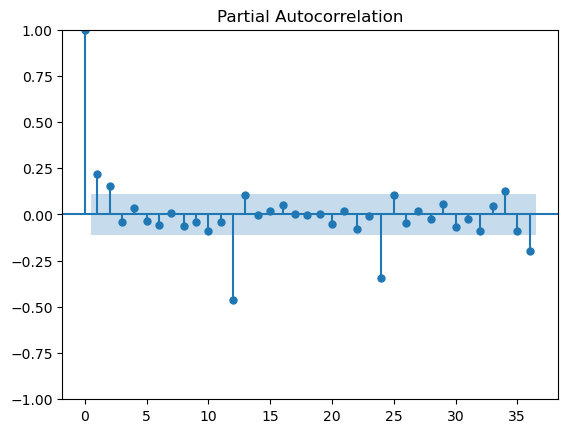

In [38]:
plot_acfs(data_sd, 't_seasdiff')

## Stationarity

In [39]:
check_stationarity(data['tdiff'], regression='c')

=== Augmented Dickey-Fuller (ADF) ===
ADF Statistic: -3.1425
p-value: 0.0236
Result: Stationary

=== Phillips–Perron (PP) ===
PP Statistic: -6.9174
p-value: 0.0000
Result: Stationary

=== KPSS ===
KPSS Statistic: 0.6332
p-value: 0.0196
Result: Non-stationary


In [40]:
check_stationarity(data['tdiff'].diff(24).dropna(), regression='c')

=== Augmented Dickey-Fuller (ADF) ===
ADF Statistic: -13.2966
p-value: 0.0000
Result: Stationary

=== Phillips–Perron (PP) ===
PP Statistic: -13.3744
p-value: 0.0000
Result: Stationary

=== KPSS ===
KPSS Statistic: 0.0396
p-value: 0.1000
Result: Stationary


In [41]:
check_stationarity(data_sd['t_seasdiff'])

=== Augmented Dickey-Fuller (ADF) ===
ADF Statistic: -7.3830
p-value: 0.0000
Result: Stationary

=== Phillips–Perron (PP) ===
PP Statistic: -13.4027
p-value: 0.0000
Result: Stationary

=== KPSS ===
KPSS Statistic: 0.0167
p-value: 0.1000
Result: Stationary
